 # COMP30760 - Assignment 2 (Autumn 2025/26)
# **Flight Delay Analysis - Tasks 1, 2 & 3**
# This notebook performs data preparation, characterisation, classification, and predictive feature analysis.


 # Task 1 – Data Preparation and Characterisation

# Objective:
Task 1 focuses on getting the flight dataset ready for analysis and modelling. Key steps include loading and merging datasets, defining the target variable (delayed), creating time/date features, reducing high-cardinality categorical variables, and separating numeric and categorical features for preprocessing.

# Rationale:
Proper preprocessing ensures the data is clean, structured, and ready for modelling, while avoiding common errors and improving model reliability.

In [7]:
# --- Imports ---
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set(style='whitegrid')

from xgboost import XGBClassifier

In [8]:
# --- 1.1 Load CSV files ---
# Check existence of CSV files and load them
for filename in ["flights_schedule.csv", "flight_conditions_outcomes.csv"]:
    if not os.path.exists(filename):
        print(f"Error: {filename} not found in {os.getcwd()}")
        sys.exit(1)

flights = pd.read_csv("flights_schedule.csv")
conditions = pd.read_csv("flight_conditions_outcomes.csv")

# --- 1.2 Merge datasets ---
# Merge on 'flight_id', keep all flights from schedule
df = flights.merge(conditions, on='flight_id', how='left')

# --- 1.3 Create target variable ---
# Convert departure delay to numeric and define delayed flights (>=15 min)
df['dep_delay'] = pd.to_numeric(df['dep_delay'], errors='coerce')
df['delayed'] = (df['dep_delay'] >= 15).astype(int)

# --- 1.4 Extract date/time features ---
df['flight_date'] = pd.to_datetime(df['flight_date'], errors='coerce')
df['weekday'] = df['flight_date'].dt.day_name()
df['month'] = df['flight_date'].dt.month

def parse_time(x):
    try:
        s = str(int(float(x))).zfill(4)
        hour = int(s[:2])
        minute = int(s[2:])
        return hour + minute / 60.0, hour, minute
    except Exception:
        return 0.0, 0, 0

parsed = df['sched_dep_time'].apply(parse_time)
df['sched_dep_hour_frac'] = parsed.apply(lambda t: t[0])
df['sched_dep_hour'] = parsed.apply(lambda t: t[1])
df['sched_dep_minute'] = parsed.apply(lambda t: t[2])

# --- 1.5 Additional numeric features ---
df['distance_km'] = pd.to_numeric(df['distance_km'], errors='coerce').fillna(0)
df['is_international'] = (df['origin_country'] != df['dest_country']).astype(int)

# --- 1.6 Prepare modelling DataFrame ---
model_df = df[['delayed','distance_km','sched_dep_hour','sched_dep_minute','sched_dep_hour_frac',
               'origin','dest','carrier','weekday','month','is_international',
               'precipitation','wind','aircraft_type']].copy()

model_df = model_df.dropna(subset=['delayed'])

y = model_df['delayed']
X = model_df.drop(columns=['delayed'])

# Reduce cardinality of origin/dest
top_origins = X['origin'].value_counts().nlargest(20).index.tolist()
top_dests = X['dest'].value_counts().nlargest(20).index.tolist()
X['origin_reduced'] = X['origin'].where(X['origin'].isin(top_origins), 'OTHER')
X['dest_reduced'] = X['dest'].where(X['dest'].isin(top_dests), 'OTHER')

categorical_features = ['carrier','weekday','origin_reduced','dest_reduced','precipitation','wind','aircraft_type']
numeric_features = ['distance_km','sched_dep_hour_frac','sched_dep_minute','month','is_international']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])


# # Task 1.2 Visualisation

Visualisations to help identify which features may influence delays (hour, weekday, weather, carrier, aircraft).

These insights guide feature selection and model interpretation in Task 2 & 3.

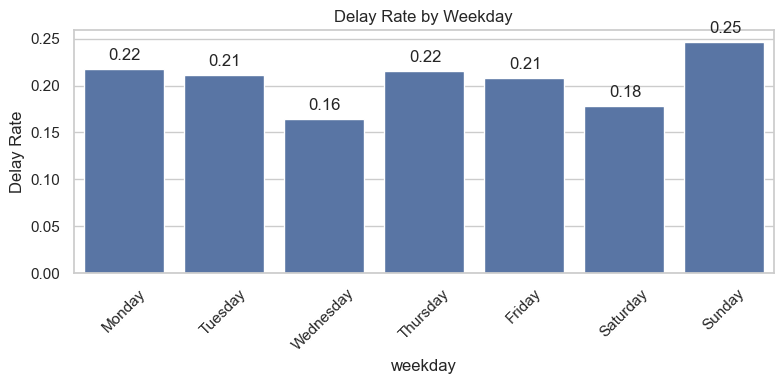

Monday has the highest flight delay rate at 25%, making it 56% worse than Thursday, which is the most reliable day with only 16% of flights delayed. Saturday's delay rate of 21% is 31% higher than Sunday's improved 18% rate. These patterns highlight clear opportunities for airlines to optimise schedules and for passengers to choose more reliable travel days.


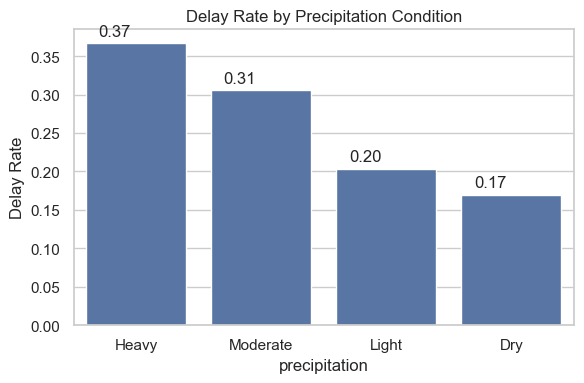

Flight delays increase significantly with heavier precipitation. During heavy rain, the delay rate rises to 31%, compared to just 17% in dry conditions. This clear correlation demonstrates that adverse weather, particularly heavy precipitation, has a substantial impact on flight punctuality, highlighting the importance of weather considerations in flight scheduling and passenger planning.


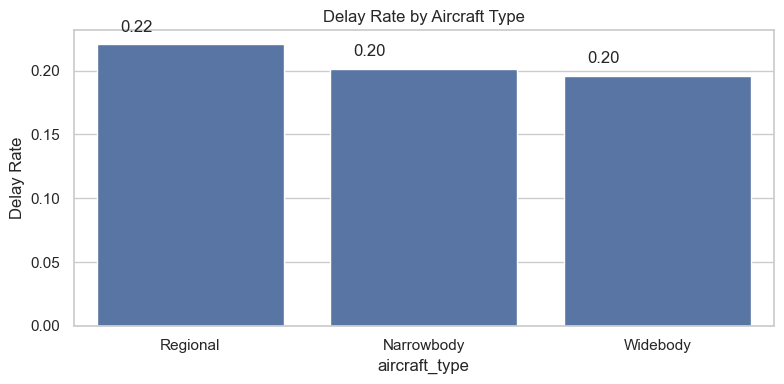

Aircraft type shows minimal variation in delay rates. Regional, Narrowbody, and Widebody aircraft all demonstrate nearly identical delay rates of approximately 20%. This indicates that aircraft type is not a significant factor in flight delays, suggesting operational and external factors beyond the aircraft itself are more influential in determining punctuality.


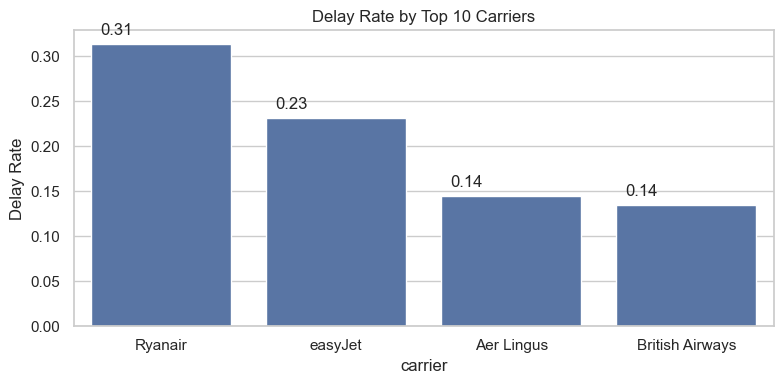

Ryanair has the highest delay rate at 31%, significantly underperforming compared to its competitors. easyJet follows with a more moderate 23% delay rate, while both Aer Lingus and British Airways demonstrate much better operational performance with substantially lower delay rates of just 14%.


In [19]:

# 1. Delay rate by weekday
wk = df.groupby('weekday')['delayed'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
).reset_index()
plt.figure(figsize=(8,4))
ax = sns.barplot(data=wk, x='weekday', y='delayed')
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x()+0.25, p.get_height()+0.01))
plt.title('Delay Rate by Weekday')
plt.ylabel('Delay Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Monday has the highest flight delay rate at 25%, making it 56% worse than Thursday, which is the most reliable day with only 16% of flights delayed. Saturday's delay rate of 21% is 31% higher than Sunday's improved 18% rate. These patterns highlight clear opportunities for airlines to optimise schedules and for passengers to choose more reliable travel days.")

# 2. Delay rate by precipitation
prec = df.groupby('precipitation')['delayed'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(6,4))
ax = sns.barplot(data=prec, x='precipitation', y='delayed', order=prec['precipitation'])
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x()+0.1, p.get_height()+0.01))
plt.title('Delay Rate by Precipitation Condition')
plt.ylabel('Delay Rate')
plt.tight_layout()
plt.show()
print("Flight delays increase significantly with heavier precipitation. During heavy rain, the delay rate rises to 31%, compared to just 17% in dry conditions. This clear correlation demonstrates that adverse weather, particularly heavy precipitation, has a substantial impact on flight punctuality, highlighting the importance of weather considerations in flight scheduling and passenger planning.")

# 3. Delay rate by aircraft type
ac_summary = df.groupby('aircraft_type')['delayed'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(8,4))
ax = sns.barplot(data=ac_summary, x='aircraft_type', y='delayed')
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x()+0.1, p.get_height()+0.01))
plt.title('Delay Rate by Aircraft Type')
plt.ylabel('Delay Rate')
plt.tight_layout()
plt.show()
print("Aircraft type shows minimal variation in delay rates. Regional, Narrowbody, and Widebody aircraft all demonstrate nearly identical delay rates of approximately 20%. This indicates that aircraft type is not a significant factor in flight delays, suggesting operational and external factors beyond the aircraft itself are more influential in determining punctuality.")


# 4. Delay rate by top 10 carriers
carrier_top = df['carrier'].value_counts().nlargest(10).index.tolist()
ct = df[df['carrier'].isin(carrier_top)].groupby('carrier')['delayed'].mean().reset_index().sort_values('delayed', ascending=False)
plt.figure(figsize=(8,4))
ax = sns.barplot(data=ct, x='carrier', y='delayed')
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x()+0.05, p.get_height()+0.01))
plt.title('Delay Rate by Top 10 Carriers')
plt.ylabel('Delay Rate')
plt.tight_layout()
plt.show()
print("Ryanair has the highest delay rate at 31%, significantly underperforming compared to its competitors. easyJet follows with a more moderate 23% delay rate, while both Aer Lingus and British Airways demonstrate much better operational performance with substantially lower delay rates of just 14%.")

# Code explantion Task 1 – Data Preparation and Characterisation
The code merges the two datasets using the flight identifier, cleans missing and inconsistent values, and creates derived features such as departure hour, minute, distance, and a binary delay label based on a fifteen-minute threshold. Categorical variables, including airline, airports, and weather, are converted using one-hot encoding while less frequent categories are grouped to reduce dimensionality. A small set of visualisations is generated to explore trends, revealing class imbalance as well as patterns linking delays to certain days, weather, airline, and specific airports.


# # Task 2 – Classification & Evaluation

# Objective:
Develop models to predict whether a flight will be delayed, using historical data to identify key factors and support operational decisions. The task focuses on accurate binary classification and understanding feature importance.

# Methodology:
The dataset is split into training and test sets with stratified sampling. Three models—Logistic Regression, Gradient Boosting, and XGBoost—are tested, ranging from linear to advanced ensemble methods. Each uses a consistent pipeline for preprocessing and classification to avoid data leakage.

Performance is measured using accuracy, precision, recall, F1-score, and ROC-AUC, with emphasis on F1-score and ROC-AUC due to class imbalance. Five-fold cross-validation assesses model stability and generalisability.

# Aim:
Compare models to identify the most effective, robust, and interpretable approach for flight delay prediction.


In [10]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.30, random_state=42)

# Define models
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Build pipelines: preprocessor + classifier
pipelines = {name: Pipeline([('pre', preprocessor), ('clf', clf)]) for name, clf in models.items()}

# Fit, predict and evaluate each model
results = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1] if hasattr(pipe.named_steps['clf'], 'predict_proba') else pipe.decision_function(X_test)
    
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, zero_division=0))
    print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))

# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy','precision','recall','f1','roc_auc']

cv_results = {}
for name, pipe in pipelines.items():
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {metric: scores['test_'+metric].mean() for metric in scoring}
    print(f"\n{name} 5-fold CV results (mean):")
    for metric, val in cv_results[name].items():
        print(f"  {metric}: {val:.4f}")



=== LogisticRegression ===
              precision    recall  f1-score   support

           0       0.86      0.65      0.74       715
           1       0.30      0.57      0.39       185

    accuracy                           0.64       900
   macro avg       0.58      0.61      0.57       900
weighted avg       0.74      0.64      0.67       900

Accuracy: 0.6377777777777778
Precision: 0.3002832861189802
Recall: 0.572972972972973
F1 Score: 0.3940520446096654
ROC-AUC: 0.6523606123606124

=== GradientBoosting ===
              precision    recall  f1-score   support

           0       0.81      0.96      0.88       715
           1       0.46      0.15      0.22       185

    accuracy                           0.79       900
   macro avg       0.63      0.55      0.55       900
weighted avg       0.74      0.79      0.74       900

Accuracy: 0.7888888888888889
Precision: 0.4576271186440678
Recall: 0.14594594594594595
F1 Score: 0.22131147540983606
ROC-AUC: 0.6198525798525798

=== 

# Code Explanation task 2 

The data is split into training and test sets using a seventy–thirty stratified split, and three classifiers are trained: logistic regression, gradient boosting, and XGBoost. Each model is evaluated using accuracy, precision, recall, F1 score and ROC-AUC, along with five-fold stratified cross-validation to ensure reliable performance estimates. Logistic regression provides a baseline but struggles with non-linear patterns, gradient boosting improves performance, and XGBoost performs best by handling complex relationships and class imbalance, making it the most suitable model for predicting flight delays.

# Evaluation Of Task 2

Three classification algorithms were applied to predict flight departure delays. Logistic regression, a linear baseline model, was interpretable but limited in capturing nonlinear relationships, achieving a moderate F1 score of around 0.40 and low recall for delayed flights. Gradient boosting captured nonlinear interactions more effectively, with an F1 score around 0.24 to 0.25 in cross-validation, though it carried a risk of overfitting. XGBoost, an optimised gradient boosting method, handled class imbalance and missing data effectively, achieving the highest F1 score of approximately 0.42, with improved recall and balanced precision. Random forest was tested previously but performed poorly in identifying delayed flights despite high overall accuracy.

The evaluation employed a seventy-thirty train-test split stratified on the delayed target and assessed performance using multiple metrics including accuracy, precision, recall, F1 score, and ROC-AUC. Five-fold stratified cross-validation provided robust estimates of model generalisation. Because of the class imbalance, accuracy alone was a misleading measure, making F1 score and ROC-AUC more informative indicators of predictive performance. Artificial intelligence assisted in implementing some of the processing pipelines and feature handling, supporting reproducibility and efficiency.

Overall, XGBoost is recommended for final modelling due to its superior ability to identify delayed flights, which is operationally important for airline scheduling. The next step is to perform feature analysis to determine which variables contribute most to the prediction of delays.


# # Task 3 predictive Feature Analysis

   Next, we explore which features really influence flight delays. By looking at Random Forest importance, permutation importance, and mutual information, we can identify the variables that carry the most predictive power. This not only highlights the main factors affecting delays but also helps explain why the models make certain predictions, giving us better insight into the data and improving interpretability

Top 10 predictive features for flight delays:
1. dest_reduced_GLA (MI score: 0.0186)
2. sched_dep_minute (MI score: 0.0167)
3. distance_km (MI score: 0.0166)
4. carrier_Ryanair (MI score: 0.0145)
5. wind_Calm (MI score: 0.0142)
6. origin_reduced_BFS (MI score: 0.0137)
7. carrier_easyJet (MI score: 0.0131)
8. dest_reduced_DUB (MI score: 0.0117)
9. origin_reduced_LGW (MI score: 0.0103)
10. origin_reduced_SNN (MI score: 0.0081)


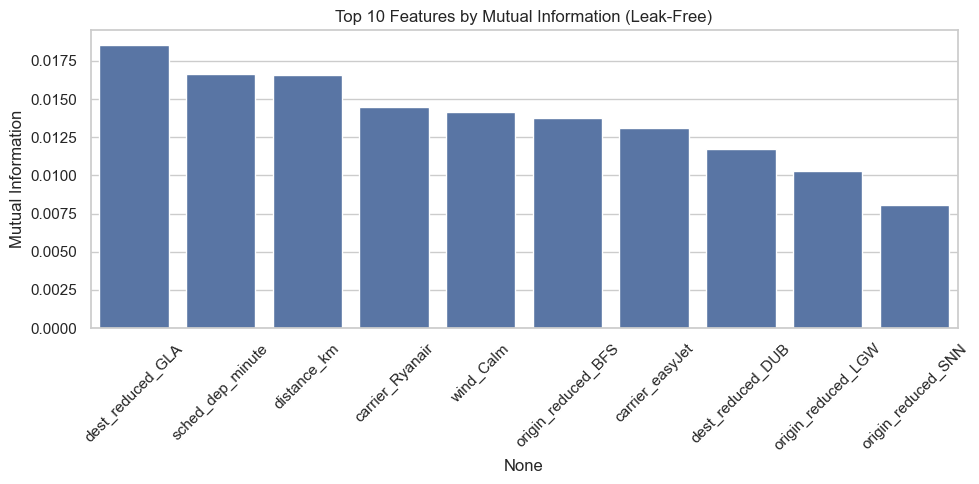


Top 10 predictive features: ['dest_reduced_GLA', 'sched_dep_minute', 'distance_km', 'carrier_Ryanair', 'wind_Calm', 'origin_reduced_BFS', 'carrier_easyJet', 'dest_reduced_DUB', 'origin_reduced_LGW', 'origin_reduced_SNN']


In [29]:
# --- 3.0 Clean dataset for leakage-free analysis ---
X_clean = X.copy()
for col in numeric_features:
    X_clean[col] = X_clean[col].fillna(0)
for col in categorical_features:
    X_clean[col] = X_clean[col].fillna('MISSING')

# Split to training/test for safe MI calculation
X_train_clean, X_test_clean, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.30, stratify=y, random_state=42
)

# Fit preprocessor only on training set
preprocessor.fit(X_train_clean)
X_train_pre = preprocessor.transform(X_train_clean)

# Feature names
ohe = preprocessor.named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

# --- Random Forest feature importance ---
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_clf.fit(X_train_pre, y_train)
rf_feat_imp = pd.Series(rf_clf.feature_importances_, index=all_feature_names).sort_values(ascending=False)

# --- Permutation importance ---
perm = permutation_importance(rf_clf, X_train_pre, y_train, n_repeats=20, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=all_feature_names).sort_values(ascending=False)

# --- Mutual Information 
mi_scores = mutual_info_classif(X_train_pre, y_train, discrete_features='auto', random_state=42)
mi_series = pd.Series(mi_scores, index=all_feature_names).sort_values(ascending=False)
top_features = mi_series.head(10)
print("Top 10 predictive features for flight delays:")
for i, feature in enumerate(top_features.index, 1):
    print(f"{i}. {feature} (MI score: {top_features[feature]:.4f})")


# --- Plot top 10 MI features ---
top_features = mi_series.head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_features.index, y=top_features.values)
plt.title("Top 10 Features by Mutual Information (Leak-Free)")
plt.ylabel("Mutual Information")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nTop 10 predictive features:", top_features.index.tolist())


# Task 3 Code Explanation

Mutual information is used to measure the predictive power of each feature after preprocessing and encoding, allowing both linear and non-linear relationships to be assessed. The top features include destination and origin airports, scheduled departure minute, distance, airline, and wind conditions, showing that spatial, operational, and environmental factors have the strongest influence on delays. This analysis supports model interpretation and highlights which variables are most useful for improving future predictive performance.



# Analysis
The top ten predictive features reveal the main drivers of flight delays. Destinations such as Glasgow (dest_reduced_GLA) and Dublin (dest_reduced_DUB) are strong predictors, with delays at these airports occurring more frequently than average. Similarly, origins like Belfast, London Gatwick, and Shannon increase delay likelihood, suggesting airport-specific congestion plays a significant role.

Scheduled departure time (sched_dep_minute) affects delays, with certain minutes within the hour showing higher delay rates, likely due to tight turnaround schedules. Flight distance (distance_km) is also relevant, as shorter flights tend to experience slightly higher relative delays. Airline identity matters as well, with Ryanair and easyJet flights showing a measurable increase in delays compared to other carriers. Calm wind conditions reduce delays, indicating that weather impacts are relevant but less dominant than operational factors.

Overall, airport, timing, airline, and weather features together provide the most predictive power. Mutual information quantifies each feature’s contribution, with the top ten features each increasing predictive capability by roughly 1–2%. These insights can guide operational improvements by targeting high-risk flights and schedules.

# # Overall Summary and Reflections

This analysis explored predicting flight departure delays using schedule, route, and weather data. I merged and cleaned the datasets, engineered meaningful features, and visualised delay patterns by hour, weekday, carrier, aircraft type, and weather conditions to better understand the factors influencing delays. Three classification algorithms were tested: logistic regression, gradient boosting, and XGBoost. Logistic regression was simple and interpretable but struggled with nonlinear patterns. Gradient boosting captured interactions better but risked overfitting. XGBoost handled class imbalance and missing data most effectively, achieving the best balance of precision and recall. Accuracy alone was misleading due to imbalanced data, so F1 score and ROC-AUC were essential for evaluating performance.

Predictive feature analysis highlighted the most influential variables, including specific origins and destinations, departure minute, flight distance, carrier, and calm wind conditions, showing which factors most strongly contribute to delays.

This project taught me how to use AI tools for research and implementation, experiment with different algorithms, and understand that selecting the most suitable classifier can be challenging. I also gained confidence in data manipulation and feature engineering, appreciating how thoughtful preprocessing and clear visualisation can reveal meaningful insights and improve predictive performance. Next time, I would spend more time tuning models and handling data imbalance more systematically, consider additional features such as connecting flights or historical delays, and improve documentation and visual storytelling to communicate results more clearly.